In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any
from pathlib import Path
import numpy as np

In [27]:
def plot_fixed_layers_vary_qubits(
    rows: list[dict[str, Any]],
    *,
    n_layers: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_layers"]) == int(n_layers)]
    if not filtered:
        logger.info("No predictions found for n_layers=%s", n_layers)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                q = int(r["n_qubits"])
                groups.setdefault(q, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[q]) for q in x]
            yerr = [np.std(groups[q], ddof=0) for q in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            q = int(r["n_qubits"])
            groups.setdefault(q, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[q]) for q in x]
        yerr = [np.std(groups[q], ddof=0) for q in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")

    plt.xlabel("Number of qubits")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    else:
        plt.show()

def plot_fixed_qubits_vary_layers(
    rows: list[dict[str, Any]],
    *,
    n_qubits: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_qubits"]) == int(n_qubits)]
    if not filtered:
        logger.info("No predictions found for n_qubits=%s", n_qubits)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                L = int(r["n_layers"])
                groups.setdefault(L, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[L]) for L in x]
            yerr = [np.std(groups[L], ddof=0) for L in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            L = int(r["n_layers"])
            groups.setdefault(L, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[L]) for L in x]
        yerr = [np.std(groups[L], ddof=0) for L in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")

    plt.xlabel("Number of layers")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    else:
        plt.show()

In [3]:
df = pd.read_csv("../outputs/figures/predictions/family/nn_predictions_random.csv")

In [4]:
df

,cid,family,seed,n_qubits,n_layers,target,prediction,error
0,random_Q10_L100_S1007406471,random,1007406471,10,100,8.001316,8.097477,0.096161
1,random_Q10_L100_S1042474350,random,1042474350,10,100,7.998677,7.919692,0.078985
2,random_Q10_L100_S1043314352,random,1043314352,10,100,8.005100,7.944589,0.060511
3,random_Q10_L100_S1070012488,random,1070012488,10,100,8.003123,8.068488,0.065365
4,random_Q10_L100_S1076020488,random,1076020488,10,100,8.001457,8.072685,0.071228
...,...,...,...,...,...,...,...,...
67495,random_Q8_L98_S852167962,random,852167962,8,98,6.015292,6.127479,0.112187
67496,random_Q8_L98_S874219491,random,874219491,8,98,6.018316,6.047062,0.028747
67497,random_Q8_L98_S960773428,random,960773428,8,98,6.047521,6.023721,0.023800
67498,random_Q8_L98_S979162145,random,979162145,8,98,6.025374,6.112576,0.087202


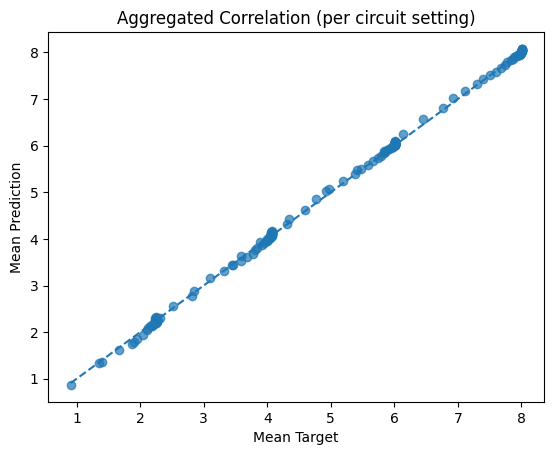

In [5]:
# aggregate over seeds
agg = df.groupby(["family", "n_qubits", "n_layers"]).mean(numeric_only=True).reset_index()

plt.figure()
plt.scatter(agg["target"], agg["prediction"], alpha=0.7)

min_val = agg["target"].min()
max_val = agg["target"].max()
plt.plot([min_val, max_val], [min_val, max_val], "--")

plt.xlabel("Mean Target")
plt.ylabel("Mean Prediction")
plt.title("Aggregated Correlation (per circuit setting)")
plt.show()

In [ ]:
agg

,family,n_qubits,n_layers,target,prediction
0,random,4,2,0.906010,0.867115
1,random,4,4,1.402406,1.354977
2,random,4,6,1.669229,1.606737
3,random,4,8,1.875388,1.755167
4,random,4,10,1.950998,1.860230
...,...,...,...,...,...
195,random,10,92,8.004130,8.048023
196,random,10,94,8.004026,8.051581
197,random,10,96,8.004560,8.066931
198,random,10,98,8.003933,8.068639


: 

In [6]:
cleaned_df = df.dropna(subset=["target", "prediction"])
grouped = cleaned_df.groupby(["family", "n_qubits", "n_layers"])

results = grouped.apply(
    lambda g: g["target"].corr(g["prediction"])
).reset_index(name="corr")

In [7]:
results

,family,n_qubits,n_layers,corr
0,random,4,2,0.609787
1,random,4,4,0.323752
2,random,4,6,0.305798
3,random,4,8,0.155402
4,random,4,10,0.019944
...,...,...,...,...
195,random,10,92,0.012675
196,random,10,94,-0.036422
197,random,10,96,0.020289
198,random,10,98,0.097526


In [8]:
agg = cleaned_df.groupby(["family", "n_qubits", "n_layers"]).agg({
    "target": "mean",
    "prediction": "mean",
}).reset_index()

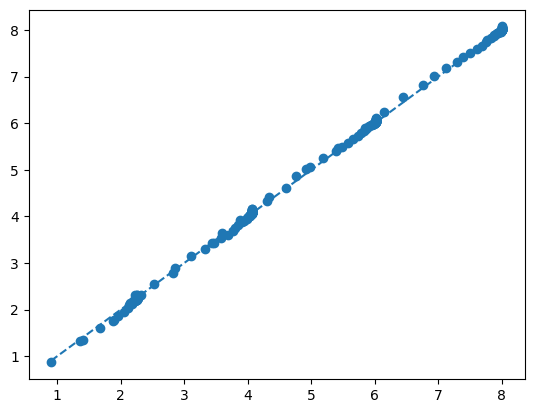

In [9]:
plt.scatter(agg["target"], agg["prediction"])
plt.plot([agg["target"].min(), agg["target"].max()],
         [agg["target"].min(), agg["target"].max()],
         "--")

Text(0, 0.5, 'Absolute Error')

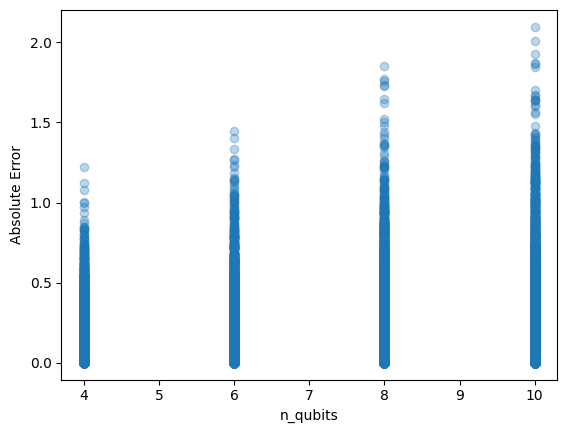

In [10]:
cleaned_df["abs_error"] = (cleaned_df["prediction"] - cleaned_df["target"]).abs()

plt.scatter(cleaned_df["n_qubits"], cleaned_df["abs_error"], alpha=0.3)
plt.xlabel("n_qubits")
plt.ylabel("Absolute Error")

In [11]:
family_df = df.groupby("family").apply(lambda x: x.sample(100))

In [12]:
print(family_df)

                                     cid        seed  n_qubits  n_layers  \
family                                                                     
random 17244  random_Q16_L72_S3328751404  3328751404        16        72   
       13655   random_Q12_L6_S1048595999  1048595999        12         6   
       17470   random_Q16_L86_S101902020   101902020        16        86   
       61732     random_Q8_L56_S81988862    81988862         8        56   
       23632  random_Q24_L42_S1140846292  1140846292        24        42   
...                                  ...         ...       ...       ...   
       59614   random_Q8_L42_S2816012805  2816012805         8        42   
       20419  random_Q20_L56_S2428698377  2428698377        20        56   
       16718  random_Q16_L46_S2725826176  2725826176        16        46   
       32861    random_Q4_L2_S2622893777  2622893777         4         2   
       32883    random_Q4_L2_S2932058031  2932058031         4         2   

           

In [13]:
df = family_df

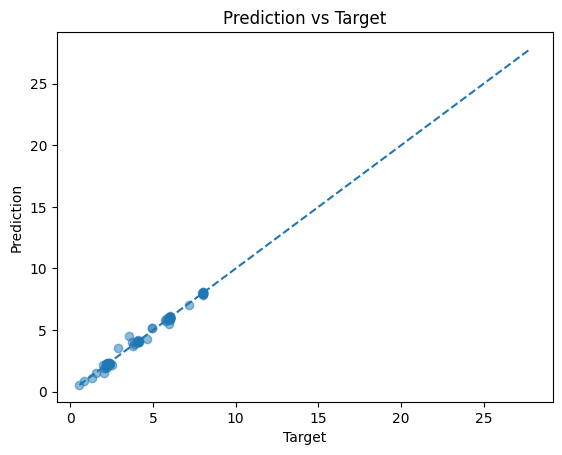

In [14]:
plt.figure()
plt.scatter(df["target"], df["prediction"], alpha=0.5)

# perfect prediction line
min_val = min(df["target"].min(), df["prediction"].min())
max_val = max(df["target"].max(), df["prediction"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title("Prediction vs Target")
plt.show()

In [15]:
corr = df["target"].corr(df["prediction"])
print("Pearson correlation:", corr)

Pearson correlation: 0.9953179074900586


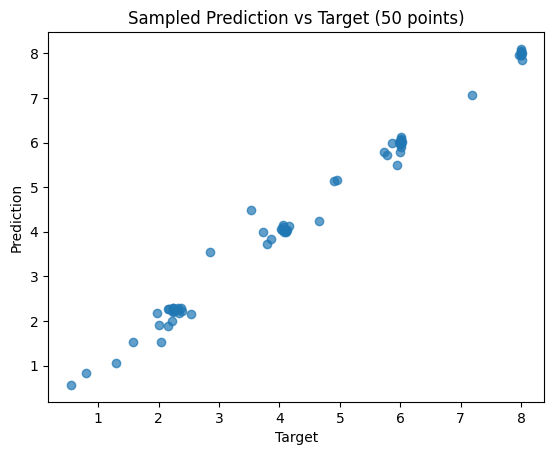

In [16]:
sample = df#.sample(300, random_state=42)

plt.figure()
plt.scatter(sample["target"], sample["prediction"], alpha=0.7)

# diagonal line
min_val = min(sample["target"].min(), sample["prediction"].min())
max_val = max(sample["target"].max(), sample["prediction"].max())
#plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title("Sampled Prediction vs Target (50 points)")
plt.show()

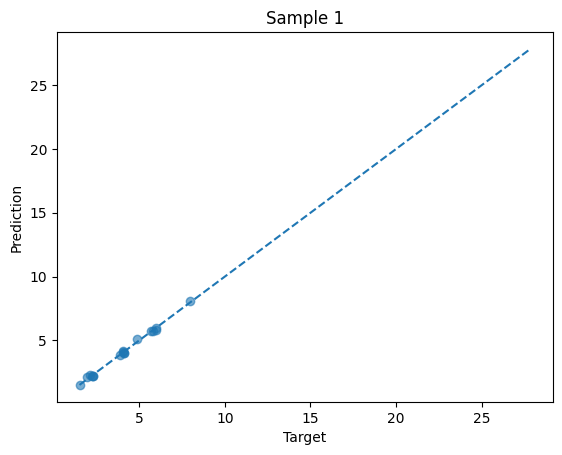

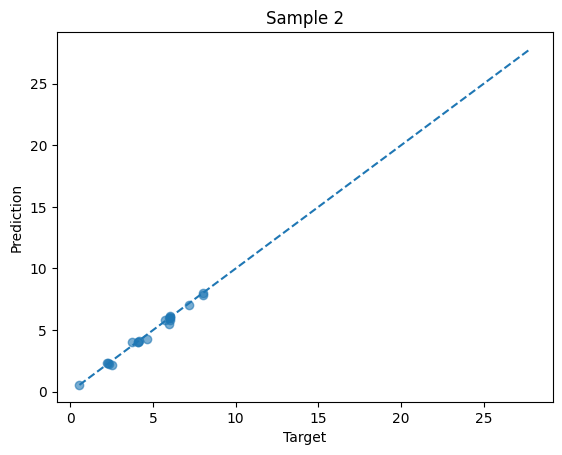

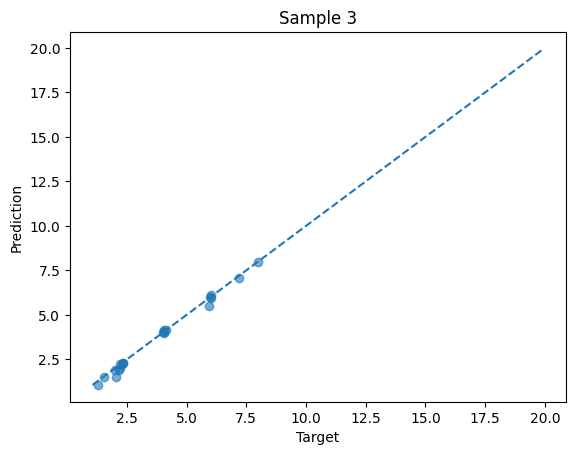

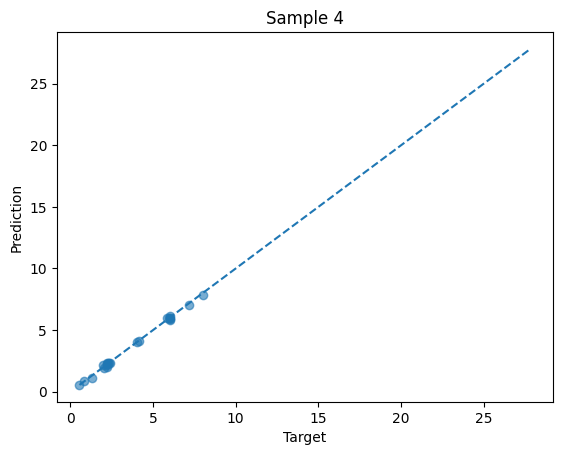

In [17]:
for i in range(4):
    sample = df.sample(30)

    plt.figure()
    plt.scatter(sample["target"], sample["prediction"], alpha=0.6)

    min_val = min(sample["target"].min(), sample["prediction"].min())
    max_val = max(sample["target"].max(), sample["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.title(f"Sample {i+1}")
    plt.xlabel("Target")
    plt.ylabel("Prediction")
    plt.show()

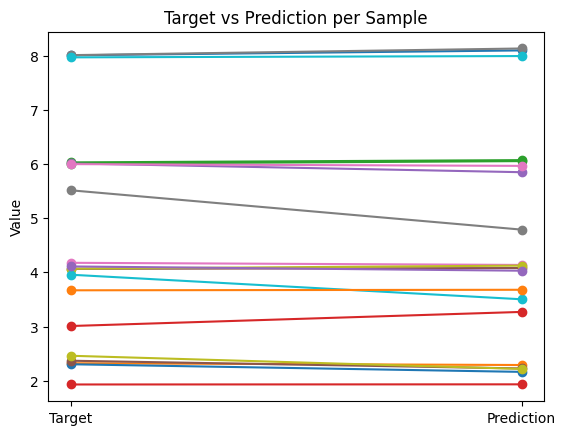

In [19]:
sample = cleaned_df.sample(20, random_state=0).reset_index(drop=True)

plt.figure()

for i in range(len(sample)):
    plt.plot([0, 1],
             [sample.loc[i, "target"], sample.loc[i, "prediction"]],
             marker="o")

plt.xticks([0, 1], ["Target", "Prediction"])
plt.ylabel("Value")
plt.title("Target vs Prediction per Sample")
plt.show()

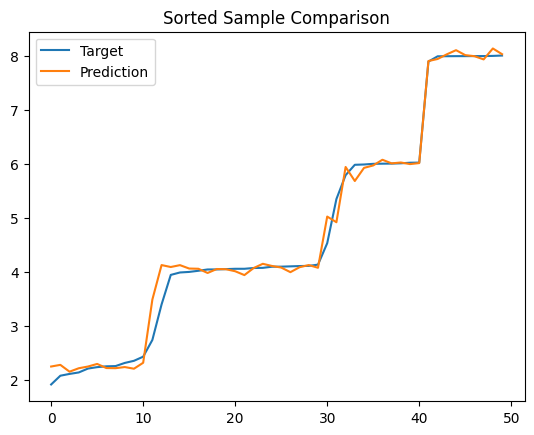

In [21]:
sample = cleaned_df.sample(50).sort_values("target").reset_index(drop=True)

plt.figure()
plt.plot(sample["target"].values, label="Target")
plt.plot(sample["prediction"].values, label="Prediction")

plt.legend()
plt.title("Sorted Sample Comparison")
plt.show()

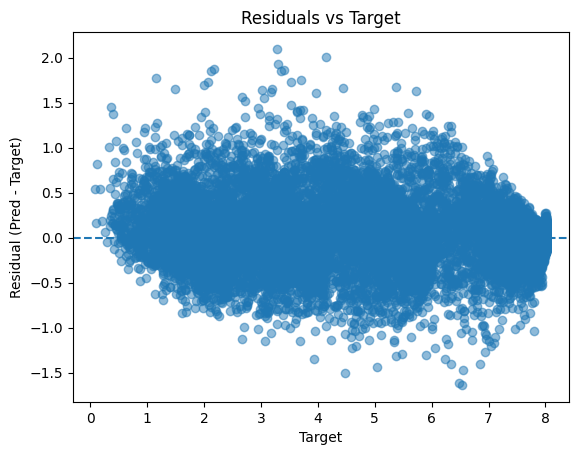

In [24]:
residuals = cleaned_df["prediction"] - cleaned_df["target"]

plt.figure()
plt.scatter(cleaned_df["target"], residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Target")
plt.ylabel("Residual (Pred - Target)")
plt.title("Residuals vs Target")
plt.show()

In [25]:
from sklearn.metrics import r2_score
df_clean = df.dropna(subset=["target", "prediction"])
r2 = r2_score(df_clean["target"], df_clean["prediction"])
print("R²:", r2)

R²: 0.9905130569077822


In [ ]:
import seaborn as sns
sns.kdeplot(x=df["target"], y=df["prediction"])



ModuleNotFoundError: No module named 'seaborn'